In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.metrics import mean_squared_log_error
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

train = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv")
submission = pd.read_csv("/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv")
TARGET = "TargetValue"
ID_COLUMN = "TransactionID"


Train shape: (138701, 50)
Test shape: (15000, 49)
   TransactionID  TargetValue  AssetID  ProductConfigID DataOriginCode  \
0        1139309      57000.0   117665               88         ACH138   
1        1139316      26500.0  1001282             4616         ACH138   
2        1139317      21000.0   772709             1948         ACH138   
3        1139322      27000.0   902010             3550         ACH138   
4        1139333      21500.0  1036259            36014         ACH138   

  VendorPartnerID  ManufactureYear  OperationalHoursMeter UtilizationTier  \
0             GTX             1997                 4640.0             Low   
1             GTX             2005                  508.0             Low   
2             GTX             1994                11540.0            High   
3             GTX             2002                 4883.0            High   
4             GTX             2009                  302.0             Low   

  TransactionDate  ...   col20            

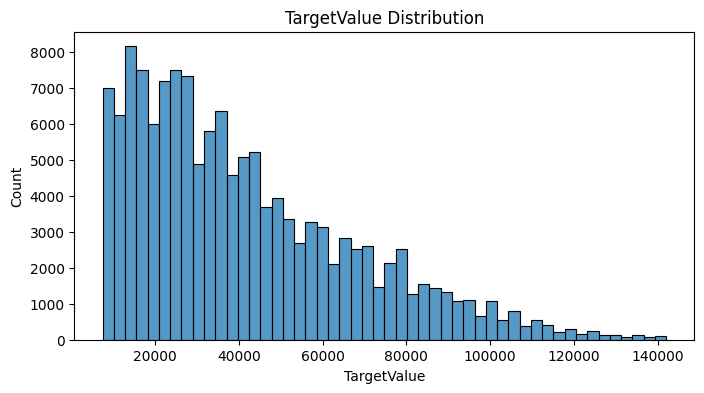

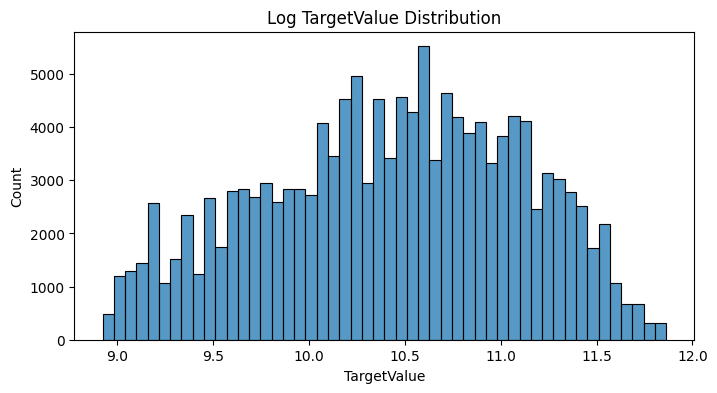

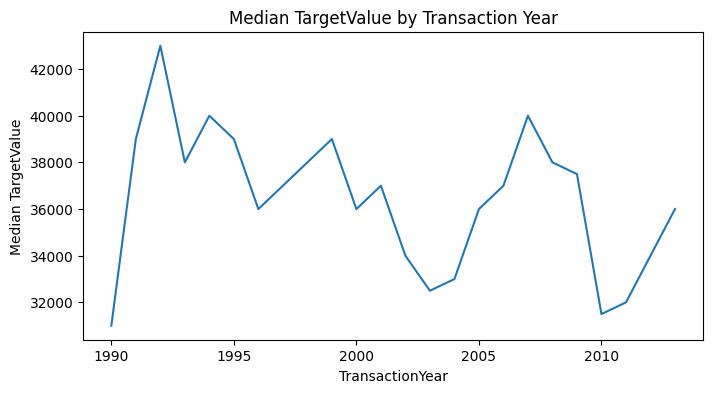

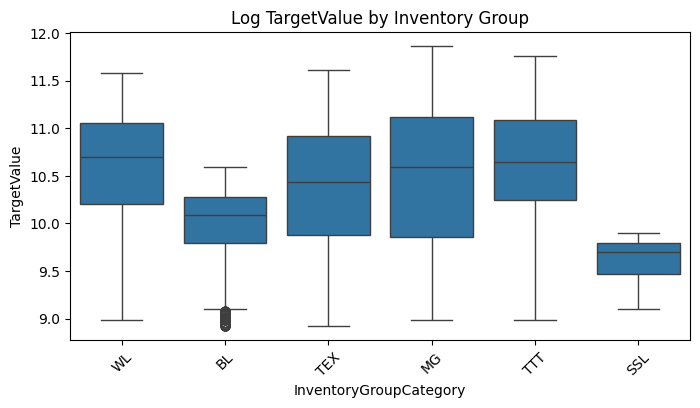

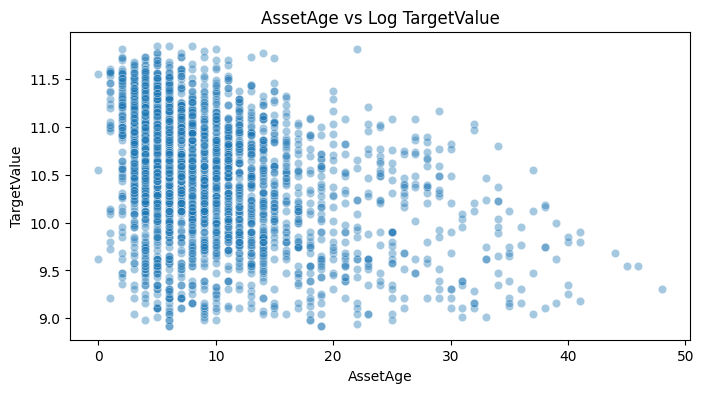

[200]	valid_0's rmse: 0.230906
[400]	valid_0's rmse: 0.214511
[600]	valid_0's rmse: 0.208977
[800]	valid_0's rmse: 0.206179
[1000]	valid_0's rmse: 0.204537
[1200]	valid_0's rmse: 0.203262
[1400]	valid_0's rmse: 0.202372
[1600]	valid_0's rmse: 0.201628
[1800]	valid_0's rmse: 0.201089
[2000]	valid_0's rmse: 0.200625
[2200]	valid_0's rmse: 0.200244
[2400]	valid_0's rmse: 0.199915
[2600]	valid_0's rmse: 0.199666
[2800]	valid_0's rmse: 0.19947
[3000]	valid_0's rmse: 0.199315
[3200]	valid_0's rmse: 0.199167
[3400]	valid_0's rmse: 0.199
[3600]	valid_0's rmse: 0.19886
[3800]	valid_0's rmse: 0.198754
[4000]	valid_0's rmse: 0.198658
[4200]	valid_0's rmse: 0.198588
[4400]	valid_0's rmse: 0.198522
[4600]	valid_0's rmse: 0.198498
[4800]	valid_0's rmse: 0.198466
[5000]	valid_0's rmse: 0.19842
[5200]	valid_0's rmse: 0.198393
[5400]	valid_0's rmse: 0.198379
[5600]	valid_0's rmse: 0.198354
[5800]	valid_0's rmse: 0.198337
[6000]	valid_0's rmse: 0.198352
LightGBM RMSLE: 0.19833262623640238
Config 1 RMSLE

In [2]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())
print(train[TARGET].describe())
print((train.isna().mean() * 100).sort_values(ascending=False).head(20))

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

def safe_str(s):
    return s.where(s.notna(), "__MISSING__").astype(str)

def add_basic_features(df):
    df = df.copy()

    date = pd.to_datetime(df["TransactionDate"], errors="coerce")

    df["TransactionYear"] = date.dt.year
    df["TransactionMonth"] = date.dt.month
    df["TransactionQuarter"] = date.dt.quarter
    df["TransactionDayOfYear"] = date.dt.dayofyear
    df["TransactionDays"] = (date - pd.Timestamp("1990-01-01")).dt.days

    df["ManufactureYear"] = pd.to_numeric(df["ManufactureYear"], errors="coerce")
    df["ManufactureYear"] = df["ManufactureYear"].where(df["ManufactureYear"].between(1900, 2020))

    df["AssetAge"] = df["TransactionYear"] - df["ManufactureYear"]
    df["AssetAge"] = df["AssetAge"].where(df["AssetAge"].between(0, 100))

    df["DescriptorLength"] = df["Spec_FullDescriptor"].fillna("").astype(str).str.len()

    df["HasOperationalHours"] = df["OperationalHoursMeter"].notna().astype("int8")

    df["HasVariantModifier"] = (
        df["Spec_VariantModifier"].notna()
        & df["Spec_VariantModifier"].astype(str).str.strip().ne("")
    ).astype("int8")

    df["LogOperationalHours"] = np.log1p(
        pd.to_numeric(df["OperationalHoursMeter"], errors="coerce").clip(lower=0)
    )
    hours = pd.to_numeric(
    df["OperationalHoursMeter"],
    errors="coerce"
)

    df["HoursPerYear"] = (
        hours / df["AssetAge"].clip(lower=1)
    ).replace([np.inf, -np.inf], np.nan)
    
    df["HoursBucket"] = (
        np.log1p(hours.clip(lower=0)) * 3
    ).round()
    
    df["MissingCount"] = df.isna().sum(axis=1).astype("int16")
    
    descriptor = df["Spec_FullDescriptor"].fillna("").astype(str)
    
    df["DescriptorNumber"] = pd.to_numeric(
        descriptor.str.extract(r"(\d+(?:\.\d+)?)", expand=False),
        errors="coerce"
    )
    
    functional = df["FunctionalClassification"].fillna("").astype(str)
    numbers = functional.str.findall(r"\d+(?:\.\d+)?")
    
    df["FunctionType"] = (
        functional.str.split(" - ").str[0].replace("", "__MISSING__")
    )
    
    df["FunctionMin"] = pd.to_numeric(
        numbers.str.get(0),
        errors="coerce"
    )
    
    df["FunctionMax"] = pd.to_numeric(
        numbers.str.get(1),
        errors="coerce"
    )
    
    df["FunctionMid"] = (
        df["FunctionMin"] + df["FunctionMax"]
    ) / 2
    
    df["FunctionRange"] = (
        df["FunctionMax"] - df["FunctionMin"]
    )
    
    return df

train_eda = add_basic_features(train)

plt.figure(figsize=(8, 4))
sns.histplot(train[TARGET], bins=50)
plt.title("TargetValue Distribution")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(train[TARGET]), bins=50)
plt.title("Log TargetValue Distribution")
plt.show()

plt.figure(figsize=(8, 4))
train_eda.groupby("TransactionYear")[TARGET].median().plot()
plt.title("Median TargetValue by Transaction Year")
plt.ylabel("Median TargetValue")
plt.show()

plt.figure(figsize=(8, 4))
top_groups = train_eda["InventoryGroupCategory"].value_counts().head(10).index
sns.boxplot(
    data=train_eda[train_eda["InventoryGroupCategory"].isin(top_groups)],
    x="InventoryGroupCategory",
    y=np.log1p(train_eda.loc[train_eda["InventoryGroupCategory"].isin(top_groups), TARGET])
)
plt.xticks(rotation=45)
plt.title("Log TargetValue by Inventory Group")
plt.show()

plt.figure(figsize=(8, 4))
sample_plot = train_eda.sample(min(3000, len(train_eda)), random_state=42)
sns.scatterplot(data=sample_plot, x="AssetAge", y=np.log1p(sample_plot[TARGET]), alpha=0.4)
plt.title("AssetAge vs Log TargetValue")
plt.show()

train_fe = add_basic_features(train)
test_fe = add_basic_features(test)

freq_cols = [
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "VendorPartnerID",
    "RegionCode",
    "InventoryGroupCategory",
    "InventoryGroupDescription"
]

def add_frequency_features(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()

    for col in cols:
        if col in train_df.columns:
            both = pd.concat([safe_str(train_df[col]), safe_str(test_df[col])], axis=0)
            counts = both.value_counts(dropna=False)

            train_df[col + "_Frequency"] = safe_str(train_df[col]).map(counts).astype("float32")
            test_df[col + "_Frequency"] = safe_str(test_df[col]).map(counts).astype("float32")

    return train_df, test_df

train_fe, test_fe = add_frequency_features(train_fe, test_fe, freq_cols)

test_ids = test_fe[ID_COLUMN].copy()

X_base = train_fe.drop(columns=[TARGET, ID_COLUMN, "AssetID", "TransactionDate"], errors="ignore")
X_test_base = test_fe.drop(columns=[ID_COLUMN, "AssetID", "TransactionDate"], errors="ignore")

y_log = np.log1p(train[TARGET])
y_true = train[TARGET]

target_encode_cols = [
    "ProductConfigID",
    "Spec_FullDescriptor",
    "Spec_BaseClass",
    "Spec_SubClass",
    "RegionCode"
]

def add_target_encoding(X_train, y_train, X_valid=None, X_test=None, cols=None):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    global_mean = y_train.mean()

    for col in cols:
        if col not in X_train.columns:
            continue

        new_col = col + "_TE"
        X_train[new_col] = np.nan

        s_train = safe_str(X_train[col])

        inner_kf = KFold(n_splits=5, shuffle=True, random_state=42)

        for tr_idx, va_idx in inner_kf.split(X_train):
            stats = y_train.iloc[tr_idx].groupby(s_train.iloc[tr_idx]).mean()

        full_stats = y_train.groupby(s_train).mean()

        X_train[new_col] = X_train[new_col].fillna(global_mean).astype("float32")

        if X_valid is not None:
            X_valid[new_col] = safe_str(X_valid[col]).map(full_stats).fillna(global_mean).astype("float32")

        if X_test is not None:
            X_test[new_col] = safe_str(X_test[col]).map(full_stats).fillna(global_mean).astype("float32")

    return X_train, X_valid, X_test

def make_sklearn_pipeline(X, model, scale_numeric=False):
    num_cols = X.select_dtypes(include=np.number).columns.tolist()
    cat_cols = [col for col in X.columns if col not in num_cols]

    num_steps = [("imputer", SimpleImputer(strategy="median"))]

    if scale_numeric:
        num_steps.append(("scaler", StandardScaler()))

    numeric_pipe = Pipeline(num_steps)

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="constant", fill_value="__MISSING__")),
        ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
    ])

    preprocess = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ])

    return Pipeline([
        ("preprocess", preprocess),
        ("model", model)
    ])

def make_lgb_categories(X_train, X_valid=None, X_test=None):
    X_train = X_train.copy()
    X_valid = None if X_valid is None else X_valid.copy()
    X_test = None if X_test is None else X_test.copy()

    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

    if "ProductConfigID" in X_train.columns and "ProductConfigID" not in cat_cols:
        cat_cols.append("ProductConfigID")

    frames = [X_train]

    if X_valid is not None:
        frames.append(X_valid)

    if X_test is not None:
        frames.append(X_test)

    for col in cat_cols:
        all_values = pd.concat([safe_str(df[col]) for df in frames], axis=0).unique()

        X_train[col] = pd.Categorical(safe_str(X_train[col]), categories=all_values)

        if X_valid is not None:
            X_valid[col] = pd.Categorical(safe_str(X_valid[col]), categories=all_values)

        if X_test is not None:
            X_test[col] = pd.Categorical(safe_str(X_test[col]), categories=all_values)

    return X_train, X_valid, X_test, cat_cols

tr_idx, va_idx = train_test_split(
    np.arange(len(X_base)),
    test_size=0.2,
    random_state=42
)

X_tr = X_base.iloc[tr_idx]
X_va = X_base.iloc[va_idx]
y_tr = y_log.iloc[tr_idx]
y_va_true = y_true.iloc[va_idx]

X_tr_te, X_va_te, _ = add_target_encoding(
    X_tr,
    y_tr,
    X_valid=X_va,
    X_test=None,
    cols=target_encode_cols
)

# models = {
#     "Ridge Linear Model": make_sklearn_pipeline(
#         X_tr_te,
#         Ridge(alpha=20),
#         scale_numeric=True
#     ),

#     "Random Forest": make_sklearn_pipeline(
#         X_tr_te,
#         RandomForestRegressor(
#             n_estimators=80,
#             max_depth=16,
#             min_samples_leaf=5,
#             random_state=42,
#             n_jobs=-1
#         ),
#         scale_numeric=False
#     )
# }

# results = []

# for name, model in models.items():
#     model.fit(X_tr_te, y_tr)
#     pred = np.expm1(model.predict(X_va_te))
#     score = rmsle(y_va_true, pred)
#     results.append([name, score])
#     print(name, "RMSLE:", score)

base_lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "n_estimators": 8000,
    "learning_rate": 0.018,
    "num_leaves": 159,
    "min_child_samples": 60,
    "subsample": 0.85,
    "subsample_freq": 1,
    "colsample_bytree": 0.85,
    "reg_alpha": 0.05,
    "reg_lambda": 3.0,
    "cat_smooth": 50,
    "cat_l2": 10,
    "random_state": 42,
    "n_jobs": -1,
    "verbosity": -1,
    "force_col_wise": True
}

X_tr_lgb, X_va_lgb, _, cat_cols = make_lgb_categories(X_tr_te, X_va_te, None)

lgb_model = lgb.LGBMRegressor(**base_lgb_params)

lgb_model.fit(
    X_tr_lgb,
    y_tr,
    categorical_feature=cat_cols,
    eval_set=[(X_va_lgb, np.log1p(y_va_true))],
    eval_metric="rmse",
    callbacks=[
        lgb.early_stopping(300, verbose=False),
        lgb.log_evaluation(200)
    ]
)

lgb_pred = np.expm1(lgb_model.predict(X_va_lgb, num_iteration=lgb_model.best_iteration_))
lgb_score = rmsle(y_va_true, lgb_pred)

#results.append(["LightGBM", lgb_score])
print("LightGBM RMSLE:", lgb_score)

#results_df = pd.DataFrame(results, columns=["Model", "Validation_RMSLE"])
#print(results_df.sort_values("Validation_RMSLE"))

from catboost import CatBoostRegressor
from sklearn.model_selection import KFold

X_cat = X_base.copy()
X_test_cat = X_test_base.copy()

cat_cols = X_cat.select_dtypes(include=["object", "category"]).columns.tolist()

if "ProductConfigID" in X_cat.columns:
    cat_cols.append("ProductConfigID")

cat_cols = list(dict.fromkeys(cat_cols))

for col in cat_cols:
    X_cat[col] = X_cat[col].fillna("__MISSING__").astype(str)
    X_test_cat[col] = X_test_cat[col].fillna("__MISSING__").astype(str)

X_cat = X_cat.replace([np.inf, -np.inf], np.nan)
X_test_cat = X_test_cat.replace([np.inf, -np.inf], np.nan)

# tuning_configs = [
#     # {
#     #     "learning_rate": 0.02,
#     #     "num_leaves": 127,
#     #     "min_child_samples": 50,
#     #     "reg_lambda": 2.0,
#     #     "cat_smooth": 40
#     # },
#     {
#         "learning_rate": 0.018,
#         "num_leaves": 159,
#         "min_child_samples": 60,
#         "reg_lambda": 3.0,
#         "cat_smooth": 50
#     },
#     # {
#     #     "learning_rate": 0.025,
#     #     "num_leaves": 95,
#     #     "min_child_samples": 35,
#     #     "reg_lambda": 1.5,
#     #     "cat_smooth": 30
#     # }
# ]

tuning_configs = [
    {
        "learning_rate": 0.018,
        "num_leaves": 159,
        "min_child_samples": 60,
        "reg_lambda": 3.0,
        "cat_smooth": 50,
    },
    {
        "learning_rate": 0.015,
        "num_leaves": 191,
        "min_child_samples": 70,
        "reg_lambda": 4.0,
        "cat_smooth": 60,
    },
    {
        "learning_rate": 0.02,
        "num_leaves": 127,
        "min_child_samples": 50,
        "reg_lambda": 2.5,
        "cat_smooth": 40,
    },
    {
        "learning_rate": 0.012,
        "num_leaves": 191,
        "min_child_samples": 80,
        "reg_lambda": 5.0,
        "cat_smooth": 80,
    },
    {
        "learning_rate": 0.018,
        "num_leaves": 223,
        "min_child_samples": 90,
        "reg_lambda": 5.0,
        "cat_smooth": 80,
    },
    {
        "learning_rate": 0.022,
        "num_leaves": 127,
        "min_child_samples": 70,
        "reg_lambda": 4.0,
        "cat_smooth": 50,
    },
]

tuning_results = []

for i, config in enumerate(tuning_configs, 1):
    params = base_lgb_params.copy()
    params.update(config)

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_tr_lgb,
        y_tr,
        categorical_feature=cat_cols,
        eval_set=[(X_va_lgb, np.log1p(y_va_true))],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(300, verbose=False),
            lgb.log_evaluation(0)
        ]
    )

    pred = np.expm1(model.predict(X_va_lgb, num_iteration=model.best_iteration_))
    score = rmsle(y_va_true, pred)

    tuning_results.append([i, score, config])
    print("Config", i, "RMSLE:", score)

tuning_results_df = pd.DataFrame(tuning_results, columns=["Config_No", "RMSLE", "Params"])
print(tuning_results_df.sort_values("RMSLE"))

best_config = tuning_results_df.sort_values("RMSLE").iloc[0]["Params"]

final_params = base_lgb_params.copy()
final_params.update(best_config)
final_params["n_estimators"] = 10000

bins = pd.qcut(
    y_log.rank(method="first"),
    q=10,
    labels=False
)

kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

valid_predictions = np.zeros(len(X_base))
test_predictions = np.zeros(len(X_test_base))
best_iterations = []

for fold, (train_idx, valid_idx) in enumerate(kf.split(X_base,bins), 1):
    X_train_fold = X_base.iloc[train_idx]
    X_valid_fold = X_base.iloc[valid_idx]

    y_train_fold = y_log.iloc[train_idx]
    y_valid_true = y_true.iloc[valid_idx]

    X_train_fold, X_valid_fold, X_test_fold = add_target_encoding(
        X_train_fold,
        y_train_fold,
        X_valid=X_valid_fold,
        X_test=X_test_base,
        cols=target_encode_cols
    )

    X_train_fold, X_valid_fold, X_test_fold, cat_cols = make_lgb_categories(
        X_train_fold,
        X_valid_fold,
        X_test_fold
   )

    model = lgb.LGBMRegressor(**final_params)

    model.fit(
        X_train_fold,
        y_train_fold,
        categorical_feature=cat_cols,
        eval_set=[(X_valid_fold, np.log1p(y_valid_true))],
        eval_metric="rmse",
        callbacks=[
            lgb.early_stopping(150, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

    valid_predictions[valid_idx] = np.expm1(
        model.predict(X_valid_fold, num_iteration=model.best_iteration_)
    )

    test_predictions += np.expm1(
        model.predict(X_test_fold, num_iteration=model.best_iteration_)
    ) / kf.n_splits

    fold_score = rmsle(y_valid_true, valid_predictions[valid_idx])

    best_iterations.append(model.best_iteration_)

    print("Fold", fold, "RMSLE:", fold_score)

valid_predictions = np.clip(valid_predictions, 0, None)
test_predictions = np.clip(test_predictions, 0, None)

cv_score = rmsle(y_true, valid_predictions)

print("Final CV RMSLE:", cv_score)
print("Average best iteration:", int(np.mean(best_iterations)))

submission[ID_COLUMN] = test_ids
submission[TARGET] = test_predictions

submission.to_csv("submission.csv", index=False)

print("Created submission.csv")
print(submission.head())


# MILESTONE-1

In [3]:
print(train.shape,test.shape)

(138701, 50) (15000, 49)


In [4]:
set(train.columns)-set(test.columns)

{'TargetValue'}

In [5]:
cols=train.select_dtypes(include='number').columns
len(cols)


6

In [6]:
missing=train.isna().sum()
missing[missing > 124800]

col4     128320
col5     128320
col18    138635
col19    138635
dtype: int64

In [7]:
train['OperationalHoursMeter'].isna().mean()*100

np.float64(40.838205924975306)

In [8]:
train['TargetValue'].median()

35000.0

In [9]:
train['ManufactureYear'].mode()[0]

np.int64(1001)

In [10]:
train['TransactionDate']=pd.to_datetime(train['TransactionDate'])
train['TransactionDate'].min()

Timestamp('1990-01-31 00:00:00')

In [11]:
train['Spec_BaseClass'].nunique()

1249

In [12]:
train['RegionCode'].value_counts().head()

RegionCode
Florida       23460
Texas         18284
California     9525
Washington     6063
Georgia        5240
Name: count, dtype: int64

In [13]:
train[train['RegionCode']=='Florida']['TargetValue'].mean()

np.float64(45007.54262574595)

In [14]:
train['UtilizationTier'].value_counts(dropna=False)

UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

In [15]:
train[['TargetValue','OperationalHoursMeter']].corr()

,TargetValue,OperationalHoursMeter
TargetValue,1.000000,0.001994
OperationalHoursMeter,0.001994,1.000000


In [16]:
train['FunctionalClassification'].value_counts().head()

FunctionalClassification
Hydraulic Excavator, Track - 21.0 to 24.0 Metric Tons      11158
Motorgrader - 145.0 to 170.0 Horsepower                     8107
Hydraulic Excavator, Track - 12.0 to 14.0 Metric Tons       7625
Backhoe Loader - 14.0 to 15.0 Ft Standard Digging Depth     7603
Hydraulic Excavator, Track - 33.0 to 40.0 Metric Tons       7440
Name: count, dtype: int64

# MILESTONE-2

In [17]:
train["TransactionDate"]=pd.to_datetime(train["TransactionDate"], errors="coerce")
train["TransactionYear"]=train["TransactionDate"].dt.year
train["TransactionQuarter"]=train["TransactionDate"].dt.quarter

train["AssetAge"]=train["TransactionYear"] - train["ManufactureYear"]

train["DescriptorLength"]=train["Spec_FullDescriptor"].fillna("").str.len()

train["HasOperationalHours"]=train["OperationalHoursMeter"].notna().astype(int)

train["HasVariantModifier"]=train["Spec_VariantModifier"].notna().astype(int)

In [18]:
train["AssetAge"].mode()[0]

np.int64(5)

In [19]:
train.groupby("TransactionQuarter")["TargetValue"].mean().sort_values(ascending=False)

TransactionQuarter
1    42873.587453
2    41408.258228
3    40619.200589
4    40562.454024
Name: TargetValue, dtype: float64

In [20]:
train["DescriptorLength"].max()

19

In [21]:
train["HasOperationalHours"].sum()

np.int64(82058)

In [22]:
train["HasVariantModifier"].mean()*100

np.float64(37.730081253920304)

In [23]:
train["ManufactureYear"].mean()

np.float64(1891.640853346407)

In [24]:
encoded = pd.get_dummies(
    train[["RegionCode","CabinType","UtilizationTier"]],
    drop_first=True
)

encoded.shape

(138701, 56)

In [25]:
corr=train.select_dtypes(include="number").corr()
corr["TargetValue"].abs().sort_values(ascending=False)

TargetValue              1.000000
AssetID                  0.238719
HasVariantModifier       0.217434
AssetAge                 0.204698
ManufactureYear          0.204439
DescriptorLength         0.061502
ProductConfigID          0.057265
TransactionQuarter       0.034442
TransactionYear          0.024497
TransactionID            0.012093
HasOperationalHours      0.009653
OperationalHoursMeter    0.001994
Name: TargetValue, dtype: float64

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

num_cols=["ManufactureYear","OperationalHoursMeter","AssetAge"]

for col in num_cols:
    train[col]=train[col].fillna(train[col].mean())

scaler=StandardScaler()
train[num_cols]=scaler.fit_transform(train[num_cols])

X= train.drop(columns=["TargetValue"])
y= train["TargetValue"]

X_train,X_val,y_train,y_val= train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape)
print(X_val.shape)

(110960, 55)
(27741, 55)


In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ["ManufactureYear","AssetAge"]

model= LinearRegression()
model.fit(X_train[features], y_train)

val_preds= model.predict(X_val[features])

r2 = r2_score(y_val, val_preds)
print(r2)

0.04182681098431851


# MILESTONE 3

In [28]:
train["CabinType"].fillna("Missing").eq("Missing").sum()

np.int64(0)

In [29]:
train["OperationalHoursMeter"].median()

0.0

In [30]:
train["SaleYear"] = pd.to_datetime(train["TransactionDate"], errors="coerce").dt.year

manufacture_year = pd.to_numeric(train["ManufactureYear"], errors="coerce")
manufacture_year = manufacture_year.replace([1000, 1001], np.nan)

train["AssetAge"] = train["SaleYear"] - manufacture_year

train["AssetAge"].median()


2008.6698301204876

In [31]:
train["HoursPerYear"]= train["OperationalHoursMeter"]/train["AssetAge"]
train["HoursPerYear"].replace([np.inf, -np.inf], np.nan).dropna().median()

0.0

In [32]:
missing_rate=train.isna().mean()
missing_rate[missing_rate>0.80]

col4     0.925156
col5     0.925156
col6     0.831256
col7     0.831256
col8     0.831256
col9     0.831256
col11    0.831256
col13    0.831256
col14    0.831256
col18    0.999524
col19    0.999524
col27    0.892149
col28    0.892149
col29    0.863938
col30    0.863938
dtype: float64

In [33]:
train["SaleYear"].mode()[0]

np.int32(2010)

In [34]:
log_target=np.log1p(train[TARGET])
log_target.std()

0.6709620692098283

In [35]:
X= train.drop(columns=["TargetValue"])
y= train["TargetValue"]

X_train,X_valid,y_train,y_valid =train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape

(110960, 57)

# MILESTONE 4


In [36]:
# train["UtilizationTier"] = train["UtilizationTier"].fillna("Unknown")
# train["PriceBand"] = pd.qcut(train["TargetValue"], q=5, labels=False)

# X = train.drop(columns="TargetValue")
# y = train["TargetValue"]

# X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.3, random_state=42, stratify=X["PriceBand"]
# )

# train_counts = X_train["PriceBand"].value_counts().sort_index().to_numpy()
# valid_counts = X_valid["PriceBand"].value_counts().sort_index().to_numpy()

# _, X_valid_ns, _, _ = train_test_split(
#     X, y, test_size=0.3, random_state=42, stratify=None
# )

# valid_counts_ns = X_valid_ns["PriceBand"].value_counts().sort_index().to_numpy()

# result_q1 = np.max(
#     np.abs(valid_counts / valid_counts.sum() - valid_counts_ns / valid_counts_ns.sum())
# )

# print(train_counts)
# print(valid_counts)
# print(valid_counts_ns)
# print(round(result_q1, 4))

In [37]:
# cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
# num_cols = ["ManufactureYear", "OperationalHoursMeter"]

# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ("cat", cat_pipe, cat_cols),
#     ("num", num_pipe, num_cols)
# ], remainder="drop")

# X_train_proc = preprocessor.fit_transform(X_train)
# X_valid_proc = preprocessor.transform(X_valid)

# print(round(float(X_train_proc.sum()), 3))

In [38]:
# from sklearn.model_selection import RandomizedSearchCV

# search = RandomizedSearchCV(
#     RandomForestRegressor(random_state=42),
#     {
#         "n_estimators": [50, 100, 200],
#         "max_depth": [5, 10, 15]
#     },
#     n_iter=5,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train_proc, y_train)
# print(search.best_params_["n_estimators"])

In [39]:
# from sklearn.ensemble import AdaBoostRegressor

# ada = AdaBoostRegressor(n_estimators=50, random_state=42)
# ada.fit(X_train_proc, y_train)

# print(round(np.var(ada.estimator_errors_), 4))

In [40]:
# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# rf.fit(X_train_proc, y_train)
# print(np.argmax(rf.feature_importances_))

In [41]:
# N = X_train_proc.shape[1]
# weights = N * 128 + 128 * 64 + 64 * 32 + 32
# print(weights)

In [42]:
# from sklearn.neural_network import MLPRegressor

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     max_iter=5,
#     batch_size=32,
#     random_state=42
# )

# mlp.fit(X_train_proc, y_train)
# print(round(mlp.loss_, 4))

In [43]:
# from sklearn.metrics import mean_absolute_error

# mlp_a = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=0.0001,
#     max_iter=5,
#     random_state=42
# )

# mlp_b = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=1.0,
#     max_iter=5,
#     random_state=42
# )

# mlp_a.fit(X_train_proc, y_train)
# mlp_b.fit(X_train_proc, y_train)

# mae_a = mean_absolute_error(y_train, mlp_a.predict(X_train_proc))
# mae_b = mean_absolute_error(y_train, mlp_b.predict(X_train_proc))

# print(round(abs(mae_a - mae_b), 4))

In [44]:
# valid_pred = mlp.predict(X_valid_proc)
# valid_mae = mean_absolute_error(y_valid, valid_pred)
# print(round(valid_mae, 4))